# Agent Concepts, Autonomy & Memory
**Module 3: GenAI & Agents | ~90 min**

- Agent vs chatbot
- Brain vs Hands
- ReAct: Thought → Action → Observation
- Planning
- Short-term vs Long-term memory
- Persistent state
- Loop termination


## Setup


In [ ]:
!pip install openai --quiet


In [1]:
from openai import OpenAI
from getpass import getpass

api_key = getpass("Enter your OpenRouter API key: ")
client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=api_key)
MODEL = "deepseek/deepseek-v4-flash-0731:free"

response = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "Reply with just the word: ready"}],
)
print(response.choices[0].message.content)


Enter your OpenRouter API key: ··········
ready


## 1. What is an Agent?

- **Chatbot:** one prompt → one answer
- **Agent:** goal + tools + a loop → keeps acting until the goal is done

| Example | Loop |
|---|---|
| Cursor / Copilot Agent | edit code → run it → read error → fix → repeat |
| Support bot | look up order → check policy → refund → email |
| Travel agent | search flights → check calendar → compare → book |
| Research agent | search → read → search again → write report |

**Pattern:** situation → decide action → do it → observe → decide next


## 2. Brain vs Hands

- **Brain** (LLM) — reasons in text, decides what's next
- **Hands** (tools) — calculator, search, DB, code — actually do things

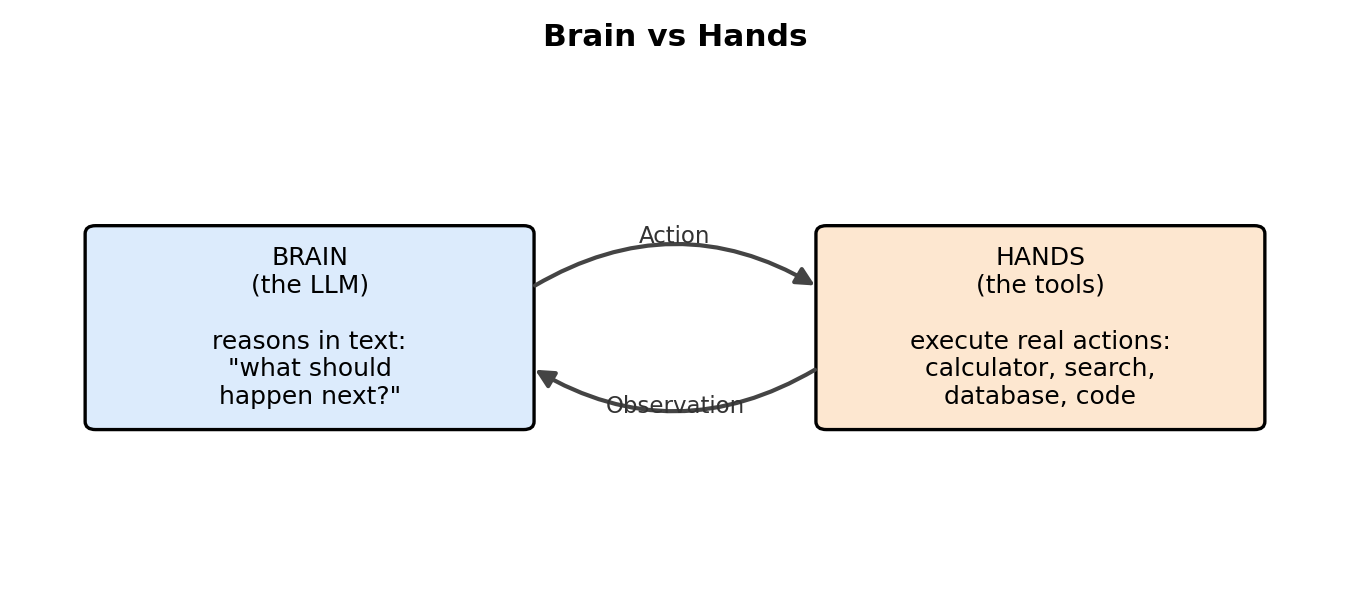


```
Brain: "calculate 47 * 12"   -> reasoning
Hands: 47 * 12 = 564         -> execution
Brain: "564 is the answer"   -> reasoning, using result
```


## 3. ReAct: Thought → Action → Observation

- **Thought** — reasoning
- **Action** — a tool call, in a fixed format
- **Observation** — the tool's real result, fed back in
- repeat → **Final Answer**

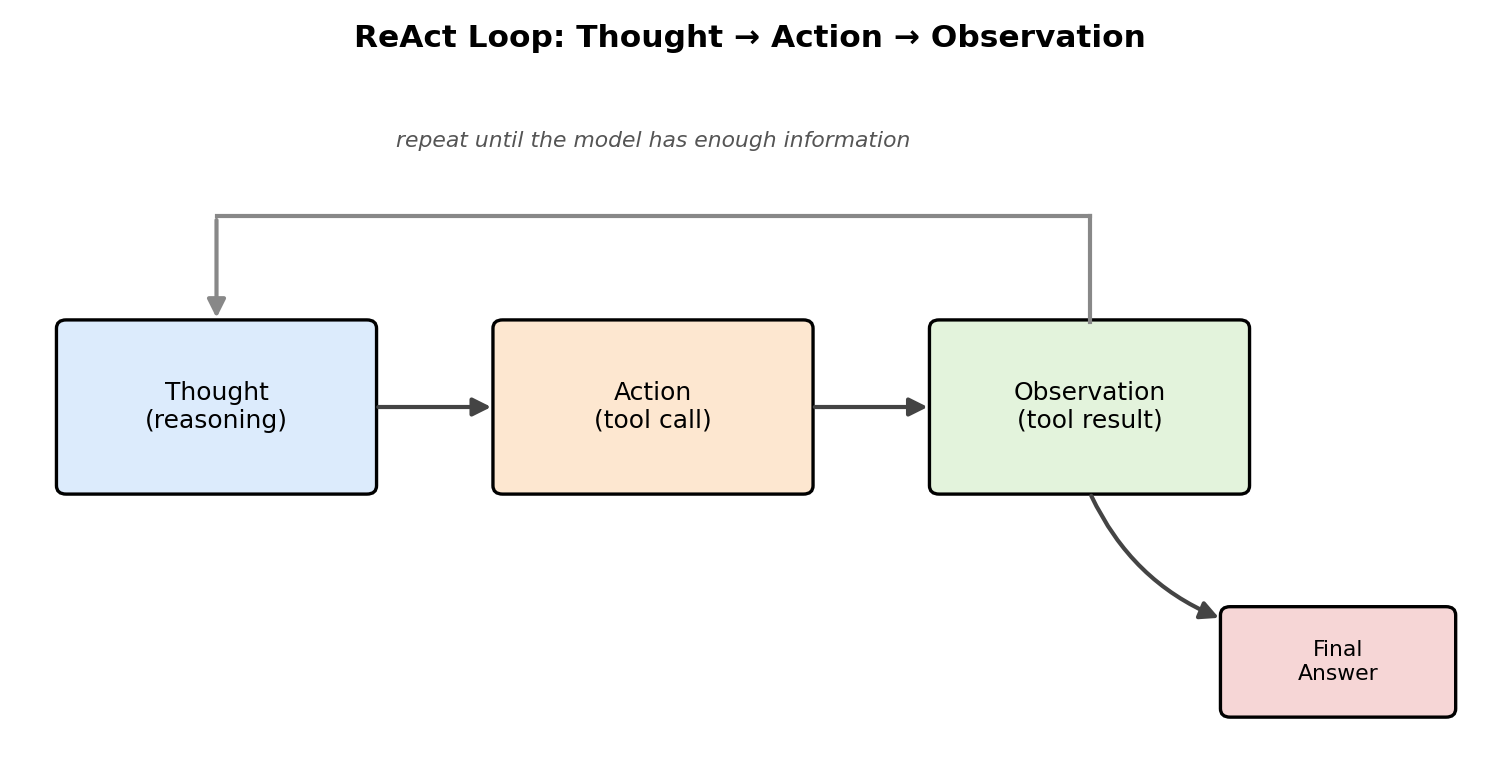


**Trace:** *"Population of the capital of France, doubled?"*
```
Thought: need capital of France
Action: lookup[capital of france]        -> Observation: Paris
Thought: need population of Paris
Action: lookup[population of paris]      -> Observation: 2148000
Thought: double it
Action: calculator[2148000 * 2]          -> Observation: 4296000
Final Answer: 4,296,000
```

Two tools: `calculator[expr]` and `lookup[key]` (fixed dictionary, stands in for a real search API).


In [2]:
knowledge_base = {
    "capital of france": "Paris",
    "population of paris": "2148000",
    "capital of japan": "Tokyo",
    "population of tokyo": "13960000",
    "capital of egypt": "Cairo",
    "population of cairo": "9500000",
}
knowledge_base


{'capital of france': 'Paris',\n 'population of paris': '2148000',\n 'capital of japan': 'Tokyo',\n 'population of tokyo': '13960000',\n 'capital of egypt': 'Cairo',\n 'population of cairo': '9500000'}

In [ ]:
react_system_prompt = '''You are an agent that solves problems by reasoning and acting in a loop.

You have exactly two tools:
- calculator[expression]  -> evaluates a math expression, e.g. calculator[12 * 4]
- lookup[key]              -> looks up a fact, e.g. lookup[capital of france]

Reply using ONLY this format, one step at a time:

Thought: <your reasoning about what to do next>
Action: <calculator[...] or lookup[...]>

When you have the final answer, reply with:

Thought: <your final reasoning>
Final Answer: <the answer>

Never answer directly without this format. Only ever output ONE Thought/Action pair per turn.
'''


In [3]:
goal = "What is the population of the capital of Japan, doubled?"

messages = [
    {"role": "system", "content": react_system_prompt},
    {"role": "user", "content": goal},
]

max_steps = 6
step = 0
final_answer = None

while step < max_steps and final_answer is None:
    step += 1

    response = client.chat.completions.create(model=MODEL, messages=messages)
    reply = response.choices[0].message.content
    print(f"--- Step {step} ---")
    print(reply)

    messages.append({"role": "assistant", "content": reply})

    if "Final Answer:" in reply:
        final_answer = reply.split("Final Answer:")[-1].strip()
        break

    action_line = [line for line in reply.split("\n") if line.strip().startswith("Action:")][0]
    action_text = action_line.split("Action:")[-1].strip()

    if action_text.startswith("calculator["):
        expression = action_text[len("calculator["):-1]
        result = eval(expression)
        observation = str(result)
    elif action_text.startswith("lookup["):
        key = action_text[len("lookup["):-1].strip().lower()
        observation = knowledge_base.get(key, "no information found")
    else:
        observation = "unknown tool requested"

    print(f"Observation: {observation}\n")
    messages.append({"role": "user", "content": f"Observation: {observation}"})

print("=" * 40)
print("FINAL ANSWER:", final_answer)


--- Step 1 ---
Thought: I need to find the capital of Japan first.
Action: lookup[capital of japan]
Observation: Tokyo

--- Step 2 ---
Thought: Now I need the population of Tokyo.
Action: lookup[population of tokyo]
Observation: 13960000

--- Step 3 ---
Thought: The question asks for double that number.
Action: calculator[13960000 * 2]
Observation: 27920000

--- Step 4 ---
Thought: I now have everything I need to answer.
Final Answer: 27,920,000
FINAL ANSWER: 27,920,000


Try: change `goal` to Egypt, re-run.


## 4. Planning

- **Reactive (ReAct):** decide one step at a time
- **Planning:** decide all steps upfront, then execute
- Production agents often do both: plan → run each step through ReAct

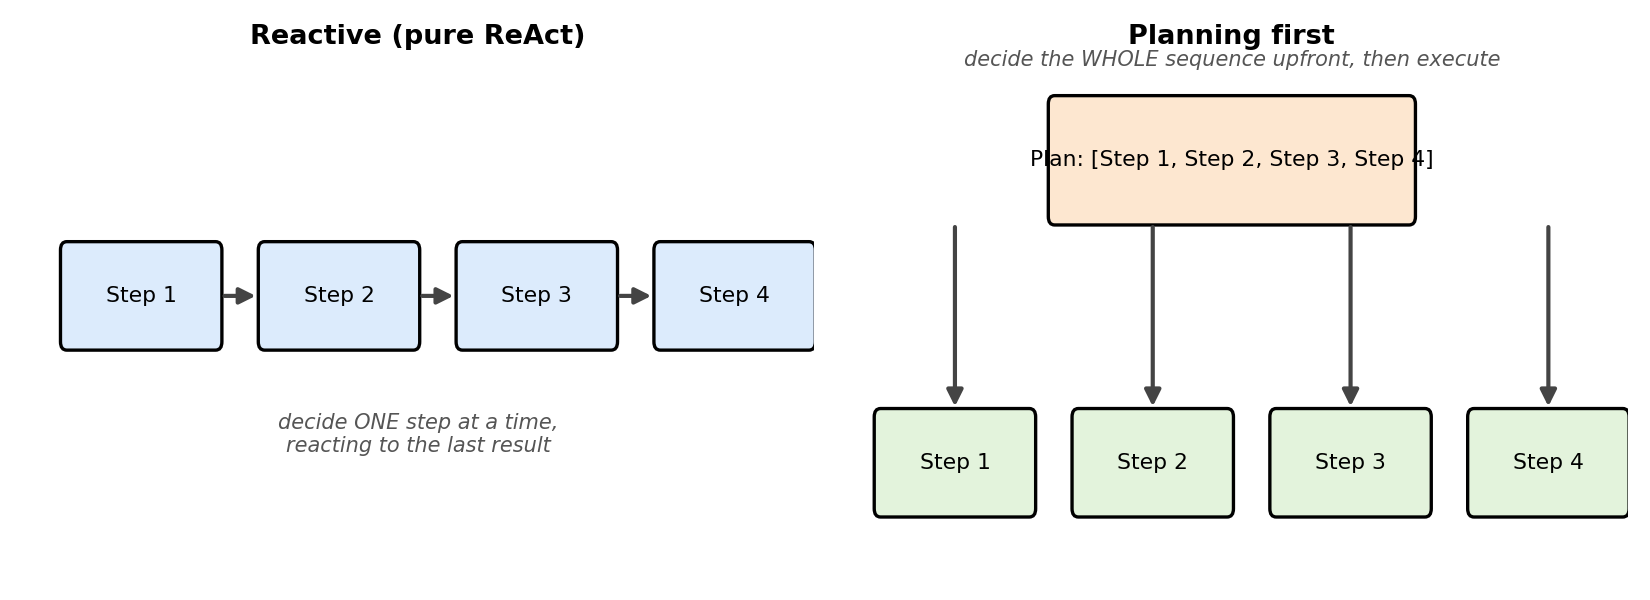


In [4]:
planning_goal = "Find the capital of Egypt, then find its population, then report double that number."

plan_prompt = f'''Break the following goal into a short numbered list of steps.
Do not solve anything yet, only list the steps.

Goal: {planning_goal}'''

plan_response = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": plan_prompt}],
)
plan_text = plan_response.choices[0].message.content
print(plan_text)


1. Look up the capital of Egypt.
2. Look up the population of that capital.
3. Multiply the population by 2.
4. Report the doubled population as the final answer.


Each planned step can be fed into the same ReAct loop above, one at a time.


## 5. Short-term vs Long-term Memory

| Short-term | Long-term |
|---|---|
| `messages` list, in RAM | file / DB / vector store |
| gone when session ends | survives a restart |

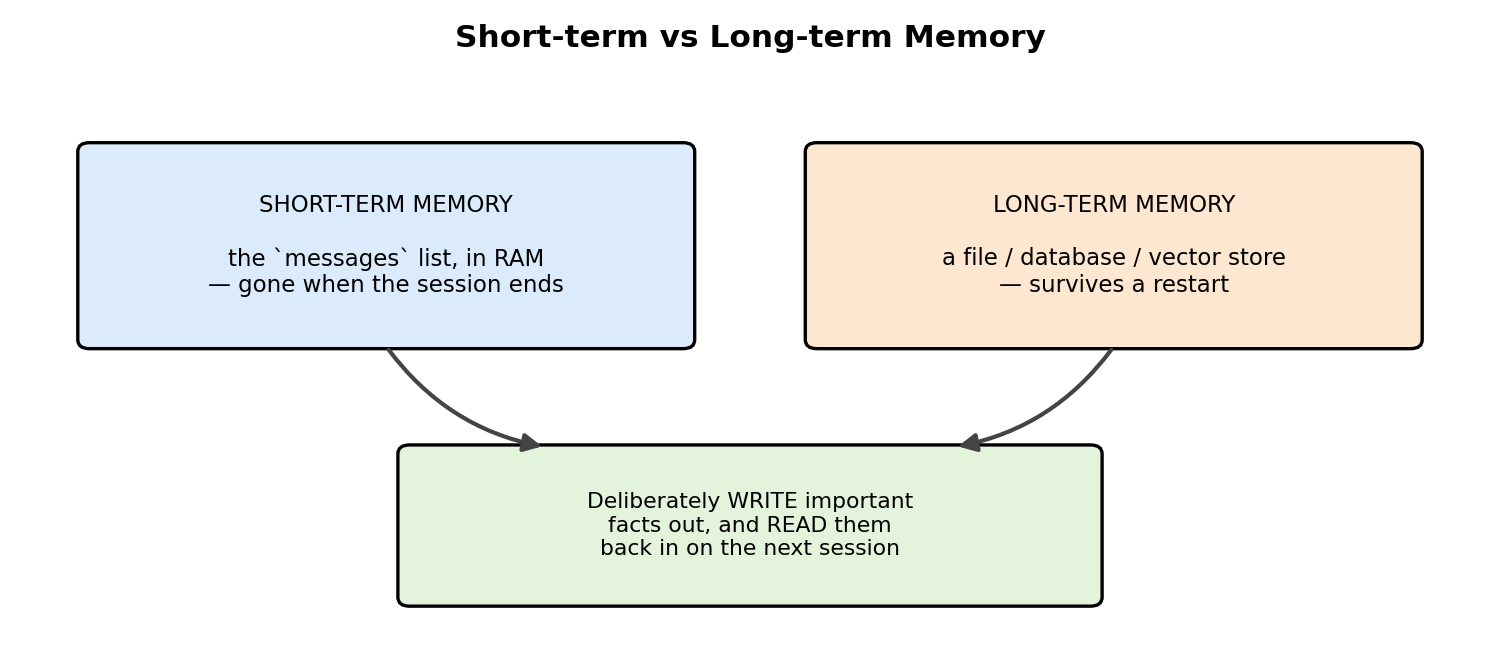


In [5]:
import json

long_term_memory = {
    "user_preference": "always report populations to the nearest thousand",
    "facts_learned": ["capital of japan is Tokyo", "population of tokyo is 13960000"],
}

with open("agent_long_term_memory.json", "w") as f:
    json.dump(long_term_memory, f, indent=2)

print("Saved to agent_long_term_memory.json")


Saved to agent_long_term_memory.json


In [6]:
# simulate a new session -- only file survives
with open("agent_long_term_memory.json", "r") as f:
    recovered_memory = json.load(f)

print(recovered_memory)


{'user_preference': 'always report populations to the nearest thousand', 'facts_learned': ['capital of japan is Tokyo', 'population of tokyo is 13960000']}


## 6. Persistent State

- **Memory** = what the agent knows. **State** = where it is in the task.
- Save state after each step → resume after a crash instead of restarting.

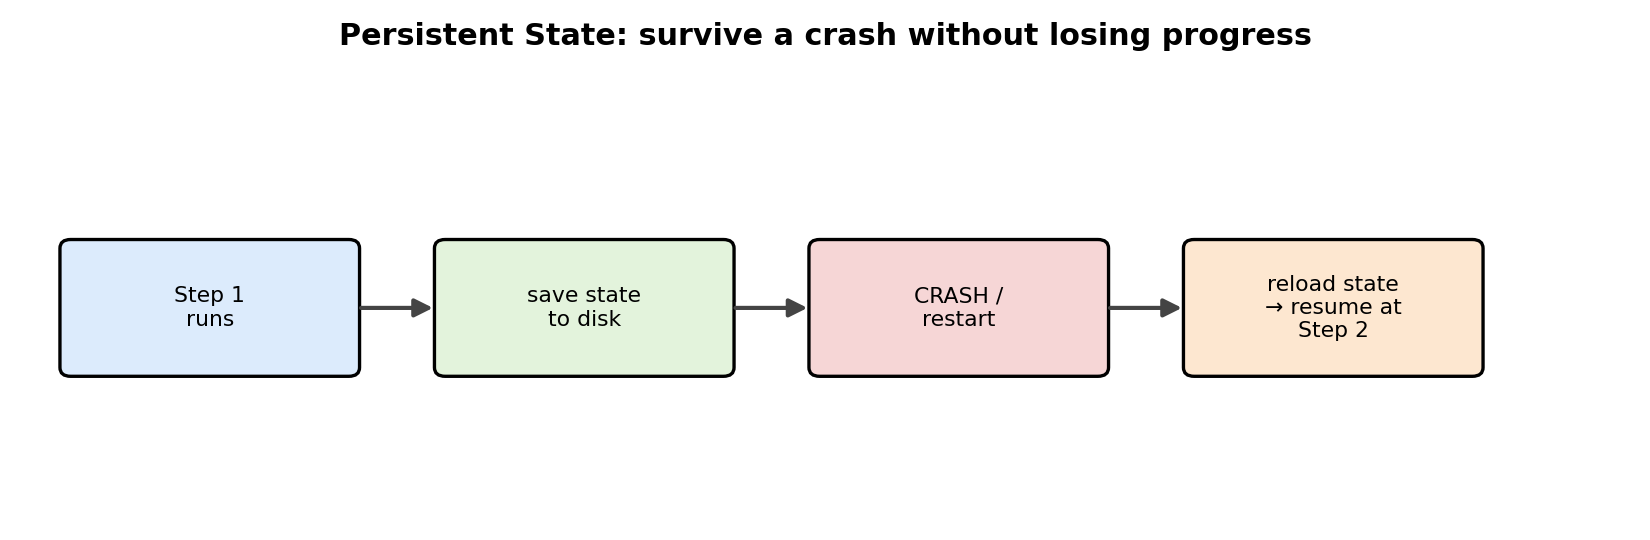


In [7]:
plan_steps = [
    "find the capital of egypt",
    "find the population of that capital",
    "double the population",
]

agent_state = {"goal": planning_goal, "current_step_index": 0, "results_so_far": {}}

with open("agent_state.json", "w") as f:
    json.dump(agent_state, f, indent=2)

print(agent_state)


{'goal': 'Find the capital of Egypt, then find its population, then report double that number.', 'current_step_index': 0, 'results_so_far': {}}


In [8]:
# step 1 runs, state saved
agent_state["results_so_far"]["capital"] = knowledge_base["capital of egypt"]
agent_state["current_step_index"] = 1

with open("agent_state.json", "w") as f:
    json.dump(agent_state, f, indent=2)

print(agent_state)


{'goal': 'Find the capital of Egypt, then find its population, then report double that number.', 'current_step_index': 1, 'results_so_far': {'capital': 'Cairo'}}


In [9]:
# simulate a crash
del agent_state
try:
    print(agent_state)
except NameError:
    print("crashed -- agent_state gone from memory\n")

# recover from disk
with open("agent_state.json", "r") as f:
    agent_state = json.load(f)

print("resumed:", agent_state)
print("next step:", plan_steps[agent_state["current_step_index"]])


crashed -- agent_state gone from memory

resumed: {'goal': 'Find the capital of Egypt, then find its population, then report double that number.', 'current_step_index': 1, 'results_so_far': {'capital': 'Cairo'}}
next step: find the population of that capital


## 7. Loop Termination

A loop must stop on:
1. **Goal reached** — `Final Answer` produced (ideal)
2. **Step limit** — `max_steps` safety cap
3. **Tool failure** — no fallback available
4. **Human interrupt** — someone stops it
5. **No progress** — same Thought/Action repeats

```python
while step < max_steps and final_answer is None:
```
This one line already covers conditions 1 and 2.


## Summary

| Concept | One-liner |
|---|---|
| Agent | LLM + tools + loop, working toward a goal |
| Brain vs Hands | LLM reasons, tools execute |
| ReAct | Thought → Action → Observation → Final Answer |
| Planning | Full sequence decided upfront |
| Short-term memory | `messages` list, gone on restart |
| Long-term memory | Saved to disk, survives restart |
| Persistent state | Saved progress, resumable after a crash |
| Loop termination | Goal / step cap / tool failure / human / no progress |

**Try:**
1. Remove `max_steps` — where does it get stuck?
2. Add a country to `knowledge_base`, change `goal`, re-run.
3. Save state again after a hypothetical step 2, reload, confirm index = 2.
